# Assignment: Exploratory Data Analysis (EDA)
### Dataset: Coffee Sales

In this assignment, we perform a comprehensive EDA on the coffee sales dataset to identify sales trends, customer preferences, and revenue patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Loading and Cleaning
We load the coffee dataset and process dates and numeric columns.

In [2]:
df = pd.read_csv('Coffee_Sales.csv')

# Convert date columns
df['date'] = pd.to_datetime(df['date'])
df['datetime'] = pd.to_datetime(df['datetime'])

# 'money' is numeric, but let's ensure it's float
df['money'] = pd.to_numeric(df['money'], errors='coerce')

print("--- Data Head ---")
print(df.head())

print("\n--- Data Info ---")
print(df.info())

--- Data Head ---
        date            datetime cash_type  money            coffee_name
0 2025-02-08 2025-02-08 14:26:04      cash   15.0                    Tea
1 2025-02-08 2025-02-08 14:28:26      cash   15.0                    Tea
2 2025-02-08 2025-02-08 14:33:04      card   20.0               Espresso
3 2025-02-08 2025-02-08 15:51:04      card   30.0  Chocolate with coffee
4 2025-02-08 2025-02-08 16:35:01      cash   27.0    Chocolate with milk

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         262 non-null    datetime64[us]
 1   datetime     262 non-null    datetime64[us]
 2   cash_type    262 non-null    str           
 3   money        262 non-null    float64       
 4   coffee_name  262 non-null    str           
dtypes: datetime64[us](2), float64(1), str(2)
memory usage: 10.4 KB
None


## 2. Basic Exploration
Analyzing missing values and descriptive statistics.

In [3]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())

Dataset Shape: (262, 5)

Missing Values:
 date           0
datetime       0
cash_type      0
money          0
coffee_name    0
dtype: int64

Statistical Summary:
                              date                    datetime      money
count                         262                         262  262.00000
mean   2025-02-28 15:01:22.442748  2025-03-01 06:16:04.549618   26.29771
min           2025-02-08 00:00:00         2025-02-08 14:26:04   15.00000
25%           2025-02-17 06:00:00  2025-02-18 01:05:45.750000   25.00000
50%           2025-02-28 00:00:00  2025-02-28 13:21:28.500000   27.00000
75%           2025-03-12 00:00:00  2025-03-12 14:52:39.500000   29.00000
max           2025-03-23 00:00:00         2025-03-23 21:23:11   33.00000
std                           NaN                         NaN    4.25021


## 3. Univariate Analysis
Examining single variables like transaction amounts and coffee popularity.

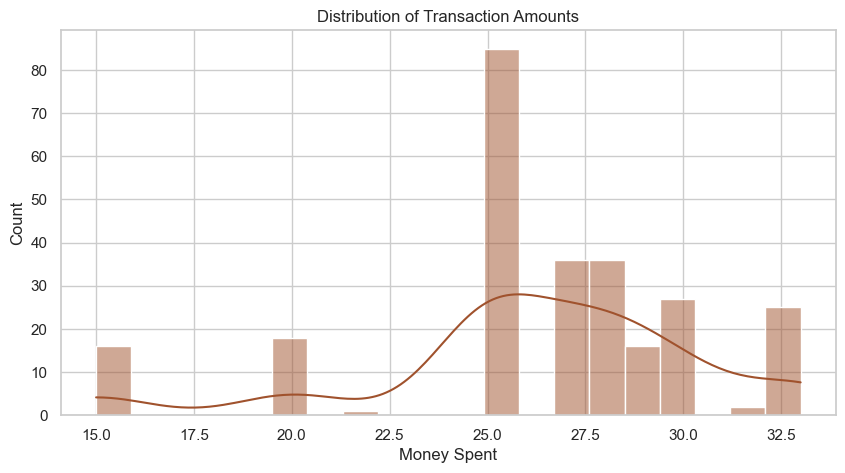

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df['money'], bins=20, kde=True, color='sienna')
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Money Spent")
plt.show()

/var/folders/3s/j41d0_ns30gbq423nh9d_flh0000gn/T/ipykernel_3182/340525193.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='coffee_name', order=df['coffee_name'].value_counts().index, palette='copper')


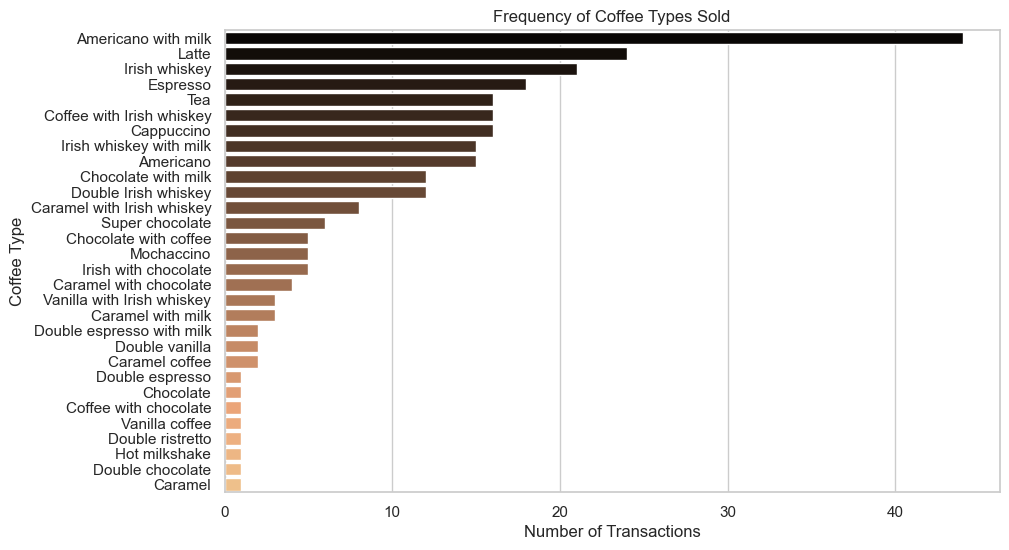

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='coffee_name', order=df['coffee_name'].value_counts().index, palette='copper')
plt.title("Frequency of Coffee Types Sold")
plt.xlabel("Number of Transactions")
plt.ylabel("Coffee Type")
plt.show()

## 4. Bivariate Analysis
Exploring relationships between two variables.

/var/folders/3s/j41d0_ns30gbq423nh9d_flh0000gn/T/ipykernel_3182/3764502918.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_coffee, x='money', y='coffee_name', palette='magma')


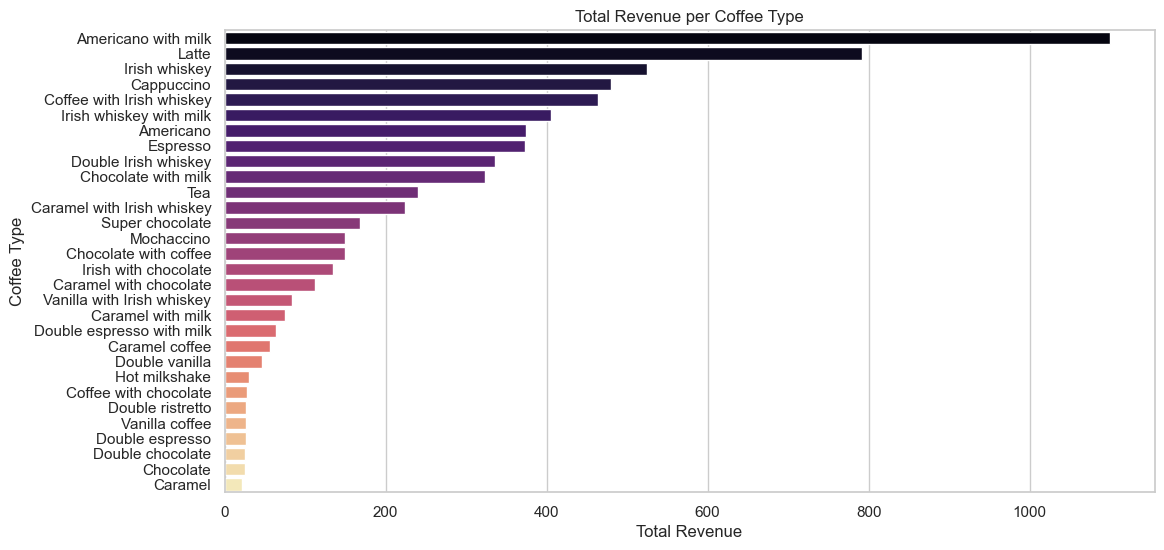

In [6]:
revenue_by_coffee = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=revenue_by_coffee, x='money', y='coffee_name', palette='magma')
plt.title("Total Revenue per Coffee Type")
plt.xlabel("Total Revenue")
plt.ylabel("Coffee Type")
plt.show()

/var/folders/3s/j41d0_ns30gbq423nh9d_flh0000gn/T/ipykernel_3182/936475192.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cash_type', y='money', data=df, palette='Set2')


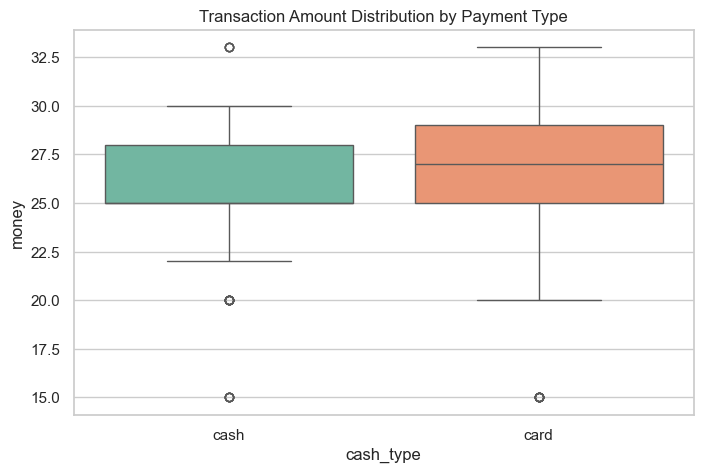

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='cash_type', y='money', data=df, palette='Set2')
plt.title("Transaction Amount Distribution by Payment Type")
plt.show()

## 5. Time-Series Analysis
Analyzing how sales change over time.

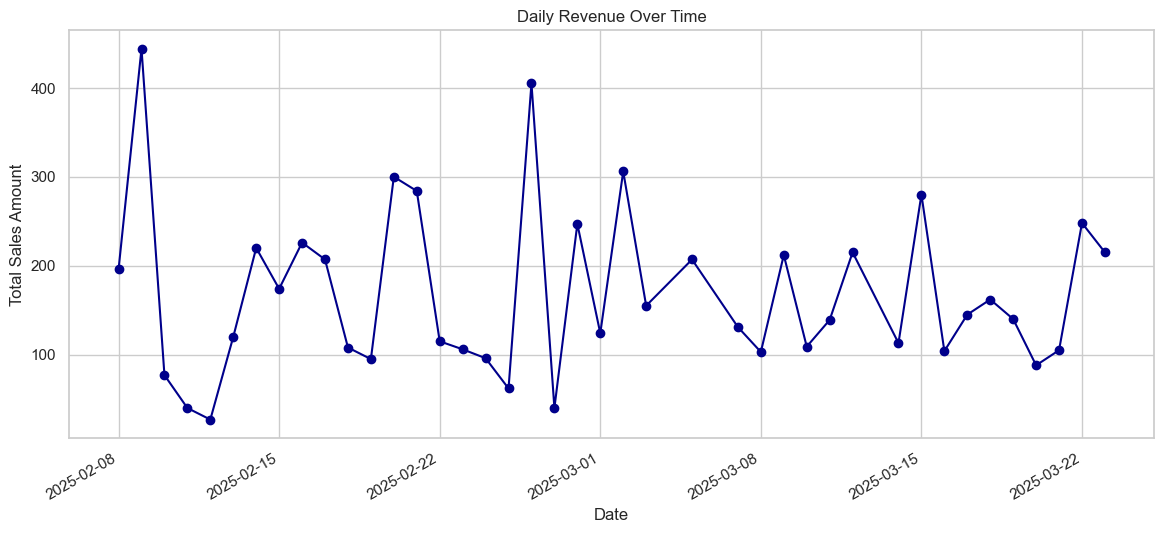

In [8]:
daily_sales = df.groupby('date')['money'].sum()

plt.figure(figsize=(14, 6))
daily_sales.plot(marker='o', linestyle='-', color='darkblue')
plt.title("Daily Revenue Over Time")
plt.ylabel("Total Sales Amount")
plt.xlabel("Date")
plt.show()

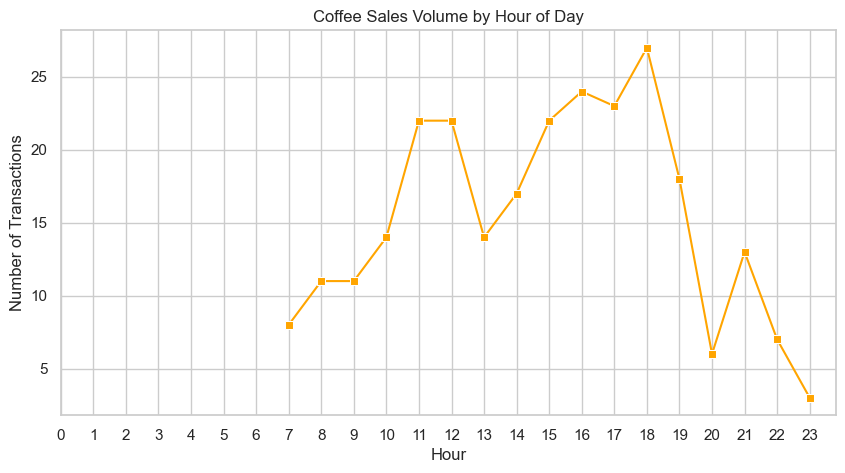

In [9]:
df['hour'] = df['datetime'].dt.hour
hourly_sales = df.groupby('hour')['money'].count()

plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, marker='s', color='orange')
plt.title("Coffee Sales Volume by Hour of Day")
plt.xticks(range(0, 24))
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")
plt.show()

## 6. Multivariate Analysis
Heatmap of sales volume by coffee type and payment method.

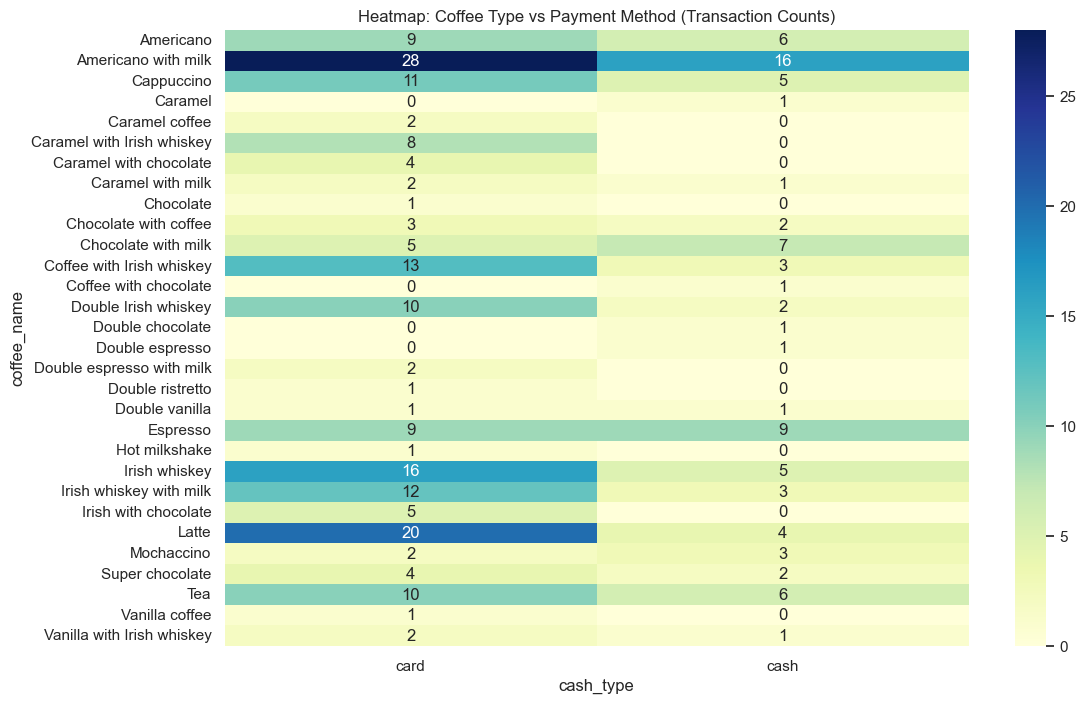

In [10]:
pivot_table = df.pivot_table(index='coffee_name', columns='cash_type', values='money', aggfunc='count', fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt='g')
plt.title("Heatmap: Coffee Type vs Payment Method (Transaction Counts)")
plt.show()